# Crop Field Management Zone Clustering

**Objective:** Discover field management zones from vegetation, moisture, soil, elevation, temperature, and nutrient measurements.

The deterministic demo data contains hidden generator profiles for post-hoc diagnostics. Those profiles are never supplied to the clustering algorithms.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Data contract and deterministic domain-shaped data


In [2]:
FEATURES = ["ndvi", "soil_moisture", "soil_ph", "elevation_m", "canopy_temp_c", "nitrogen_index"]
PROFILE_CENTERS = {
  "high_vigor": [
    0.82,
    34,
    6.7,
    115,
    25,
    0.78
  ],
  "water_stressed": [
    0.42,
    12,
    6.5,
    120,
    35,
    0.46
  ],
  "nutrient_limited": [
    0.51,
    25,
    5.7,
    108,
    30,
    0.3
  ],
  "balanced": [
    0.68,
    28,
    6.4,
    118,
    28,
    0.62
  ]
}
rows = []
for profile, centers in PROFILE_CENTERS.items():
    centers = np.asarray(centers, dtype=float)
    scales = np.maximum(np.abs(centers) * 0.10, 0.08)
    samples = rng.normal(centers, scales, size=(125, len(FEATURES)))
    samples = np.maximum(samples, 0)
    for row in samples:
        rows.append({**dict(zip(FEATURES, row)), "generator_profile": profile})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
for column in FEATURES[:2]:
    missing_rows = rng.choice(data.index, size=8, replace=False)
    data.loc[missing_rows, column] = np.nan
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset shape: 500 rows × 7 columns


,ndvi,soil_moisture,soil_ph,elevation_m,canopy_temp_c,nitrogen_index,generator_profile
0,0.735,20.727,5.279,101.345,27.448,0.214,nutrient_limited
1,0.766,35.455,6.573,118.780,25.905,0.886,high_vigor
2,0.549,23.449,4.798,99.958,29.836,0.393,nutrient_limited
3,0.420,12.538,7.257,139.769,36.084,0.507,water_stressed
4,0.859,32.186,6.424,130.670,22.399,0.587,high_vigor


,count,mean,std,min,25%,50%,75%,max
ndvi,492.0,0.602,0.174,0.198,0.463,0.581,0.749,0.996
soil_moisture,492.0,24.664,8.395,7.622,18.828,26.183,30.733,43.907
soil_ph,500.0,6.297,0.760,4.364,5.749,6.320,6.850,8.646
elevation_m,500.0,115.582,12.750,78.303,106.996,115.310,123.493,153.711
canopy_temp_c,500.0,29.458,4.638,18.975,26.018,29.188,32.398,43.049
nitrogen_index,500.0,0.538,0.197,0.067,0.374,0.550,0.690,0.988


## 3. Robust preprocessing and cluster-count selection


In [3]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", RobustScaler())])
X = preprocessor.fit_transform(data[FEATURES])
selection_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE).fit_predict(X)
    selection_rows.append({"k": k, "silhouette": silhouette_score(X, labels), "davies_bouldin": davies_bouldin_score(X, labels)})
selection = pd.DataFrame(selection_rows)
display(selection.round(4))
best_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} by maximum silhouette score.")


Selected k=3 by maximum silhouette score.


,k,silhouette,davies_bouldin
0,2,0.3377,1.2166
1,3,0.3386,1.1116
2,4,0.2788,1.3622
3,5,0.2541,1.4058
4,6,0.2238,1.4882


## 4. Compare algorithms and retain the clearer solution


In [4]:
kmeans = KMeans(n_clusters=best_k, n_init=40, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X)
hierarchical_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X)

comparison = pd.DataFrame([
    {"model": "K-Means", "silhouette": silhouette_score(X, kmeans_labels), "davies_bouldin": davies_bouldin_score(X, kmeans_labels)},
    {"model": "Agglomerative", "silhouette": silhouette_score(X, hierarchical_labels), "davies_bouldin": davies_bouldin_score(X, hierarchical_labels)},
])
display(comparison.round(4))
labels = kmeans_labels if comparison.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True]).iloc[0]["model"] == "K-Means" else hierarchical_labels
selected_model = "K-Means" if np.array_equal(labels, kmeans_labels) else "Agglomerative"
data["cluster"] = labels
print(f"Selected solution: {selected_model}")


Selected solution: K-Means


,model,silhouette,davies_bouldin
0,K-Means,0.3386,1.1116
1,Agglomerative,0.3329,1.0922


## 5. Profile and visualize the discovered groups


Retrospective ARI against hidden generator profiles: 0.6195


,records,ndvi,soil_moisture,soil_ph,elevation_m,canopy_temp_c,nitrogen_index
cluster,,,,,,,
0,230,0.755,31.182,6.622,118.062,26.205,0.710
1,153,0.515,24.678,5.680,106.885,29.830,0.336
2,117,0.424,12.111,6.463,122.080,35.368,0.462


cluster,0,1,2,All
generator_profile,,,,
balanced,106,19,0,125
high_vigor,124,1,0,125
nutrient_limited,0,124,1,125
water_stressed,0,9,116,125
All,230,153,117,500


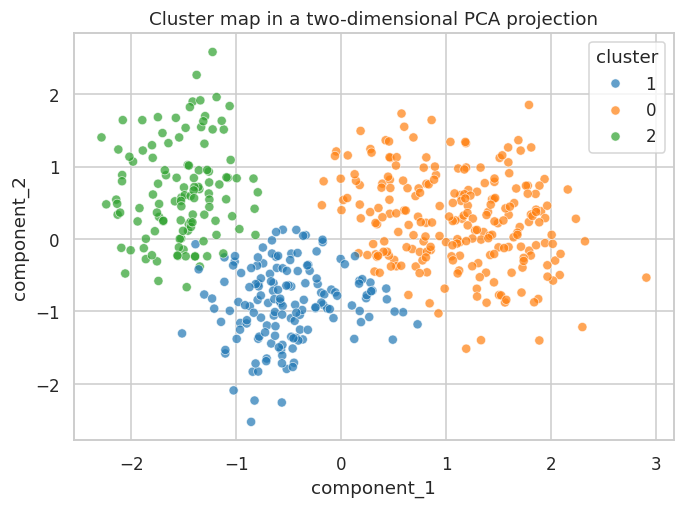

In [5]:
from sklearn.decomposition import PCA

profiles = data.groupby("cluster")[FEATURES].mean().round(3)
profiles.insert(0, "records", data.groupby("cluster").size())
display(profiles)
display(pd.crosstab(data["generator_profile"], data["cluster"], margins=True))
print(f"Retrospective ARI against hidden generator profiles: {adjusted_rand_score(data['generator_profile'], data['cluster']):.4f}")

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "cluster": data["cluster"].astype(str)})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("Cluster map in a two-dimensional PCA projection")
plt.tight_layout()
plt.show()


## 6. Stability and assignment example


In [6]:
alternate = KMeans(n_clusters=best_k, n_init=40, random_state=7).fit_predict(X)
print(f"K-Means stability across seeds (ARI): {adjusted_rand_score(kmeans_labels, alternate):.4f}")
if selected_model == "K-Means":
    example = data[FEATURES].median().to_frame().T
    predicted = int(kmeans.predict(preprocessor.transform(example))[0])
    display(example.round(3).assign(predicted_cluster=predicted))
else:
    print("Agglomerative clustering has no native out-of-sample predict method; production assignment would use centroids or a trained surrogate.")


K-Means stability across seeds (ARI): 1.0000


,ndvi,soil_moisture,soil_ph,elevation_m,canopy_temp_c,nitrogen_index,predicted_cluster
0,0.581,26.183,6.32,115.31,29.188,0.55,0


## 7. Findings and limitations

- Multiple internal metrics and a seed-stability check are used because clustering has no single accuracy measure.
- Hidden generator profiles provide only a retrospective pipeline check.
- Production interpretation requires domain validation, drift monitoring, and explicit rules for acting on segments.
